In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import igraph as ig
import leidenalg as la
from dotenv import load_dotenv
import psycopg2
from sqlalchemy import create_engine, text
import time


env_file = Path("assemble-graph-database/.env")
if env_file.exists():
    load_dotenv(env_file)
    print(f"✓ Loaded environment variables from {env_file}")
else:
    print(f"⚠️  .env file not found at {env_file}")
    print("💡 Using default values")

# Configure display settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✓ Libraries imported successfully")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Numpy version: {np.__version__}")

output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)

✓ Loaded environment variables from assemble-graph-database/.env
✓ Libraries imported successfully
✓ Pandas version: 2.3.2
✓ Numpy version: 2.3.2


## Database Connection Setup

Connect to PostgreSQL database to load the graph data.

In [2]:
# PostgreSQL Database connection configuration

# Database connection parameters
DB_HOST = os.getenv('DB_HOST', '127.0.0.1')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'postgres')
DB_NAME = os.getenv('DB_NAME', 'steam_reviews')
DB_SSLMODE = os.getenv('DB_SSLMODE', 'disable')

# PostgreSQL connection string
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode={DB_SSLMODE}"

print(f"🐘 Connecting to PostgreSQL database:")
print(f"   Host: {DB_HOST}:{DB_PORT}")
print(f"   Database: {DB_NAME}")
print(f"   User: {DB_USER}")

# Connect to database
try:
    # Create SQLAlchemy engine for pandas integration
    engine = create_engine(connection_string)

    # Test connection with direct psycopg2
    conn = psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD,
        database=DB_NAME
    )

    print(f"✓ Connected to PostgreSQL database: {DB_HOST}:{DB_PORT}/{DB_NAME}")

    # Get database size information
    cursor = conn.cursor()
    cursor.execute("""
        SELECT pg_size_pretty(pg_database_size(%s)) as db_size;
    """, (DB_NAME,))
    db_size = cursor.fetchone()[0]
    print(f"✓ Database size: {db_size}")
    cursor.close()

    # For pandas compatibility, we'll use the engine for pd.read_sql_query
    # Note: conn is psycopg2 connection, engine is SQLAlchemy engine

except Exception as e:
    print(f"❌ Database connection failed: {e}")
    print(f"💡 Make sure PostgreSQL is running and the database exists.")
    print(f"💡 Run: cd graph-analyser/assemble-graph-database && docker compose --env-file assemble-graph-database/.env up -d")
    raise

🐘 Connecting to PostgreSQL database:
   Host: 127.0.0.1:25432
   Database: steam_reviews
   User: postgres
✓ Connected to PostgreSQL database: 127.0.0.1:25432/steam_reviews
✓ Database size: 27 GB


## Load igraph into memory

Load nodes (games) and edges (game_projection_edges) from the PostgreSQL database.

In [ ]:
print("Loading games (nodes) from database...")

# Load games table as nodes
games_query = """
SELECT 
    game_id,
    name,
    steam_appid,
    price_currency,
    price_final,
    price_initial,
    categories_ids,
    genre_ids,
    release_date,
    rating_dejus_rating,
    rating_dejus_required_age,
    degree,
    component_id,
    projection_degree,
    projection_weighted_degree,
    projection_harmonic_centrality,
    projection_betweenness_centrality,
    leiden_1_5_res_community,
    leiden_0_5_res_community
FROM games

ORDER BY game_id
"""

games_df = pd.read_sql(games_query, engine)

print(f"✓ Loaded {len(games_df):,} games (nodes)")
print(f"  Memory usage: {games_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nSample of games data:")
print(games_df.head())
print("\nGames data info:")
print(games_df.info())

Loading games (nodes) from database...
✓ Loaded 98,101 games (nodes)
  Memory usage: 60.10 MB

Sample of games data:
   game_id                            name  steam_appid price_currency  \
0       10                  Counter-Strike           10            BRL   
1      100  Counter-Strike: Condition Zero           80            BRL   
2  1000000                       ASCENXION      1000000            BRL   
3  1000010                     Crown Trick      1000010            BRL   
4  1000030     Cook, Serve, Delicious! 3?!      1000030            BRL   

   price_final  price_initial  \
0       2069.0         2069.0   
1       2069.0         2069.0   
2       3299.0         3299.0   
3      10490.0        10490.0   
4       3799.0         3799.0   

                                      categories_ids       genre_ids  \
0             [1, 49, 36, 37, 66, 68, 75, 69, 8, 62]             [1]   
1                      [2, 1, 66, 68, 78, 69, 8, 62]             [1]   
2                      

In [ ]:
print("Loading game projection edges from database...")

# Load game_projection_edges table
edges_query = """
SELECT 
    game_id_1,
    game_id_2,
    weight
FROM game_projection_edges
INNER JOIN games AS g1 ON game_projection_edges.game_id_1 = g1.game_id
INNER JOIN games AS g2 ON game_projection_edges.game_id_2 = g2.game_id
ORDER BY id
"""

edges_df = pd.read_sql(edges_query, engine)

print(f"✓ Loaded {len(edges_df):,} edges")
print(f"  Memory usage: {edges_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nSample of edges data:")
print(edges_df.head())
print("\nEdge weight statistics:")
print(edges_df['weight'].describe())

Loading game projection edges from database...
✓ Loaded 49,997,708 edges
  Memory usage: 5669.52 MB

Sample of edges data:
  game_id_1 game_id_2  weight
0        10       100    1889
1        10      1002      13
2        10    100400       2
3        10     10090    1656
4        10     10100       9

Edge weight statistics:
count    4.999771e+07
mean     6.564536e+00
std      7.909629e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      7.183900e+04
Name: weight, dtype: float64


### Build igraph Graph

Construct the igraph object from the loaded nodes and edges.

In [8]:
print("Building igraph from database data...")

# Create a mapping from game_id to vertex index
game_id_to_idx = {game_id: idx for idx, game_id in enumerate(games_df['game_id'])}

# Create list of edges using vertex indices
edge_list = []
edge_weights = []

for _, row in edges_df.iterrows():
    game1_idx = game_id_to_idx.get(row['game_id_1'])
    game2_idx = game_id_to_idx.get(row['game_id_2'])
    
    if game1_idx is not None and game2_idx is not None:
        edge_list.append((game1_idx, game2_idx))
        edge_weights.append(row['weight'])

# Create the igraph Graph
g = ig.Graph(n=len(games_df), edges=edge_list, directed=False)

# Add edge weights
g.es['weight'] = edge_weights

# Add vertex attributes from games dataframe
for col in games_df.columns:
    g.vs[col] = games_df[col].tolist()

print(f"\n✓ Graph constructed successfully!")
print(f"  Vertices: {g.vcount():,}")
print(f"  Edges: {g.ecount():,}")
print(f"  Directed: {g.is_directed()}")
print(f"  Weighted: {'weight' in g.es.attributes()}")
print(f"\nVertex attributes: {g.vs.attributes()}")
print(f"Edge attributes: {g.es.attributes()}")

Building igraph from database data...

✓ Graph constructed successfully!
  Vertices: 98,101
  Edges: 49,997,708
  Directed: False
  Weighted: True

Vertex attributes: ['game_id', 'name', 'steam_appid', 'price_currency', 'price_final', 'price_initial', 'categories_ids', 'genre_ids', 'release_date', 'rating_dejus_rating', 'rating_dejus_required_age', 'degree', 'component_id', 'projection_degree', 'projection_weighted_degree', 'projection_harmonic_centrality', 'projection_betweenness_centrality', 'leiden_1_5_res_community', 'leiden_0_5_res_community']
Edge attributes: ['weight']


In [9]:
g.write_graphml("../hardrive_mount/projected_graph_with_names_and_communities.graphml")

In [3]:
g: ig.Graph = ig.read(
    "../hardrive_mount/projected_graph_with_names_and_communities.graphml")

### Graph Summary Statistics

Display basic statistics about the loaded graph.

In [8]:
print("=" * 60)
print("GRAPH SUMMARY STATISTICS")
print("=" * 60)

# Basic graph properties
print(f"\n📊 Graph Size:")
print(f"  Number of vertices (games): {g.vcount():,}")
print(f"  Number of edges: {g.ecount():,}")
print(f"  Graph density: {g.density():.6f}")

# Degree statistics
degrees = g.degree()
print(f"\n📈 Degree Statistics:")
print(f"  Mean degree: {np.mean(degrees):.2f}")
print(f"  Median degree: {np.median(degrees):.2f}")
print(f"  Max degree: {max(degrees):,}")
print(f"  Min degree: {min(degrees):,}")

# Weight statistics
weights = g.es['weight']
print(f"\n⚖️  Edge Weight Statistics:")
print(f"  Mean weight: {np.mean(weights):.2f}")
print(f"  Median weight: {np.median(weights):.2f}")
print(f"  Max weight: {max(weights):,}")
print(f"  Min weight: {min(weights):,}")
print(f"  Total weight: {sum(weights):,}")

# Connected components
components = g.connected_components()
print(f"\n🔗 Connected Components:")
print(f"  Number of components: {len(components):,}")
print(f"  Largest component size: {max(len(c) for c in components):,} vertices")
print(f"  Smallest component size: {min(len(c) for c in components):,} vertices")

# Memory usage
print(f"\n💾 Memory Usage:")
print(f"  Games DataFrame: {games_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Edges DataFrame: {edges_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 60)

GRAPH SUMMARY STATISTICS

📊 Graph Size:
  Number of vertices (games): 98,101
  Number of edges: 49,997,708
  Graph density: 0.010391

📈 Degree Statistics:
  Mean degree: 1019.31
  Median degree: 0.00
  Max degree: 21,531
  Min degree: 0
  Median degree: 0.00
  Max degree: 21,531
  Min degree: 0

⚖️  Edge Weight Statistics:

⚖️  Edge Weight Statistics:
  Mean weight: 6.56
  Mean weight: 6.56
  Median weight: 1.00
  Max weight: 71,839
  Median weight: 1.00
  Max weight: 71,839
  Min weight: 1
  Total weight: 328,211,772

🔗 Connected Components:
  Number of components: 65,866
  Min weight: 1
  Total weight: 328,211,772

🔗 Connected Components:
  Number of components: 65,866
  Largest component size: 32,220 vertices
  Smallest component size: 1 vertices

💾 Memory Usage:
  Games DataFrame: 58.61 MB
  Edges DataFrame: 5669.52 MB

  Largest component size: 32,220 vertices
  Smallest component size: 1 vertices

💾 Memory Usage:
  Games DataFrame: 58.61 MB
  Edges DataFrame: 5669.52 MB



## Run Leiden clustering (community detection)

In [ ]:
print("=" * 60)
print("LEIDEN COMMUNITY DETECTION")
print("=" * 60)

# Configure Leiden algorithm
print("\n🔬 Running Leiden algorithm for community detection...")
print(f"  Graph size: {g.vcount():,} vertices, {g.ecount():,} edges")
print(f"  Using edge weights: Yes")
print(f"  Quality function: CPM (Constant Potts Model)")
print("\n⏳ This may take several minutes for large graphs...")

# Run Leiden algorithm with CPM quality function
# Using weights for better community detection
start_time = time.time()

# Note: leidenalg doesn't have built-in progress bars, but we can show start/end
partition = la.find_partition(
    g, 
    la.CPMVertexPartition,
    weights='weight',
    # resolution_parameter=0.5,  # larger, broader communities
    resolution_parameter=1.5,  # smaller, more granular communities
    n_iterations=-1,  # Run until convergence
    seed=42  # For reproducibility
)

elapsed_time = time.time() - start_time

print(f"\n✓ Leiden algorithm completed in {elapsed_time:.2f} seconds")
print(f"  Number of communities found: {len(partition)}")
print(f"  Modularity: {partition.modularity:.4f}")
print(f"  Quality (CPM): {partition.quality():.4f}")

# Add community membership to graph vertices
g.vs['community_1.5'] = partition.membership

print("\n✓ Community assignments added to graph vertices")
print("=" * 60)

LEIDEN COMMUNITY DETECTION

🔬 Running Leiden algorithm for community detection...
  Graph size: 98,101 vertices, 49,997,708 edges
  Using edge weights: Yes
  Quality function: CPM (Constant Potts Model)

⏳ This may take several minutes for large graphs...

✓ Leiden algorithm completed in 1733.94 seconds
  Number of communities found: 80254
  Modularity: 0.0144
  Quality (CPM): 490364212.0000

✓ Community assignments added to graph vertices


### Store result in database

In [23]:
print("=" * 60)
print("STORING LEIDEN COMMUNITY RESULTS IN DATABASE")
print("=" * 60)

# Create DataFrame with game_id and community_id
leiden_communities_df = pd.DataFrame({
    'game_id': [v['game_id'] for v in g.vs],
    'leiden_1_5_res_community': [v['community_1.5'] for v in g.vs]
})

print(f"\n📊 Prepared data for {len(leiden_communities_df):,} games")
print(f"  Communities range: {leiden_communities_df['leiden_1_5_res_community'].min()} to {leiden_communities_df['leiden_1_5_res_community'].max()}")

# Create a temporary table for efficient bulk update
print("\n🗄️  Updating database...")
with engine.begin() as connection:
    # Add column if it doesn't exist, or set to NULL if it does
    connection.execute(text("""
        ALTER TABLE games 
        ADD COLUMN IF NOT EXISTS leiden_1_5_res_community INTEGER
    """))
    
    connection.execute(text("""
        UPDATE games 
        SET leiden_1_5_res_community = NULL
    """))

    # Create temporary table
    connection.execute(text("""
        CREATE TEMP TABLE temp_leiden_communities (
            game_id VARCHAR(255) PRIMARY KEY,
            leiden_1_5_res_community INTEGER
        )
    """))

    # Insert data into temporary table
    leiden_communities_df.to_sql('temp_leiden_communities', connection,
                                  if_exists='append', index=False)

    # Update main table from temporary table
    result = connection.execute(text("""
        UPDATE games g
        SET leiden_1_5_res_community = t.leiden_1_5_res_community
        FROM temp_leiden_communities t
        WHERE g.game_id = t.game_id
    """))

    # Drop temporary table
    connection.execute(text("DROP TABLE temp_leiden_communities"))
    
    print(f"✓ Updated {result.rowcount:,} rows in games table")

# Verify the update
verification_query = """
SELECT 
    COUNT(*) as total_games,
    COUNT(leiden_1_5_res_community) as games_with_community,
    COUNT(DISTINCT leiden_1_5_res_community) as unique_communities
FROM games
"""
verification_df = pd.read_sql(verification_query, engine)

print(f"\n✅ Verification:")
print(f"  Total games: {verification_df['total_games'].iloc[0]:,}")
print(f"  Games with community: {verification_df['games_with_community'].iloc[0]:,}")
print(f"  Unique communities: {verification_df['unique_communities'].iloc[0]:,}")

print("\n" + "=" * 60)

STORING LEIDEN COMMUNITY RESULTS IN DATABASE

📊 Prepared data for 98,101 games
  Communities range: 0 to 80253

🗄️  Updating database...
✓ Updated 98,101 rows in games table

✅ Verification:
  Total games: 98,101
  Games with community: 98,101
  Unique communities: 80,254



### Load from the database

In [4]:
print("=" * 60)
print("LOADING LEIDEN COMMUNITIES FROM DATABASE")
print("=" * 60)

# Load community assignments from database
community_query = """
SELECT 
    game_id,
    COALESCE(leiden_0_5_res_community, -1) AS leiden_0_5_res_community,
    COALESCE(leiden_1_5_res_community, -1) AS leiden_1_5_res_community
FROM games
-- WHERE 
--  leiden_0_5_res_community IS NOT NULL AND
--  leiden_1_5_res_community IS NOT NULL
ORDER BY game_id
"""

communities_df = pd.read_sql(community_query, engine)
communities_df.set_index('game_id', inplace=True)

print(f"\n✓ Loaded {len(communities_df):,} games with community assignments")

# Assign communities to vertices
community_0_5_membership = []
community_1_5_membership = []
for v in g.vs:
    comm_0_5_id, comm_1_5_id = communities_df.loc[v['game_id'], ['leiden_0_5_res_community', 'leiden_1_5_res_community']].values
    community_0_5_membership.append(comm_0_5_id)
    community_1_5_membership.append(comm_1_5_id)

g.vs['community_0.5'] = community_0_5_membership
g.vs['community_1.5'] = community_1_5_membership

# Reconstruct partition from membership
partition_0_5 = la.CPMVertexPartition(g, initial_membership=community_0_5_membership, weights='weight', resolution_parameter=0.5)
partition_1_5 = la.CPMVertexPartition(g, initial_membership=community_1_5_membership, weights='weight', resolution_parameter=1.5)

print(f"\n✓ Partition 0.5 resolution reconstructed:")
print(f"  Number of communities: {len(partition_0_5)}")
print(f"  Modularity: {partition_0_5.modularity:.4f}")
print(f"  Quality (CPM): {partition_0_5.quality():.4f}")

print(f"\n✓ Partition 1.5 resolution reconstructed:")
print(f"  Number of communities: {len(partition_1_5)}")
print(f"  Modularity: {partition_1_5.modularity:.4f}")
print(f"  Quality (CPM): {partition_1_5.quality():.4f}")

print("\n" + "=" * 60)

LOADING LEIDEN COMMUNITIES FROM DATABASE

✓ Loaded 98,101 games with community assignments

✓ Partition 0.5 resolution reconstructed:
  Number of communities: 72137
  Modularity: 0.0407
  Quality (CPM): 552794644.0000

✓ Partition 1.5 resolution reconstructed:
  Number of communities: 80254
  Modularity: 0.0144
  Quality (CPM): 490364212.0000



## Community Detection Results (0.5 resolution)

Analyze the communities detected by the Leiden algorithm.


In [17]:
def display_community_statistics(partition):
  # Detailed community statistics
  print("=" * 60)
  print("COMMUNITY STATISTICS")
  print("=" * 60)

  # Get community sizes
  community_sizes = partition.sizes()
  community_ids = range(len(partition))

  # Create DataFrame with community information
  community_stats = pd.DataFrame({
      'community_id': community_ids,
      'size': community_sizes
  })

  # Sort by size descending
  community_stats = community_stats.sort_values('size', ascending=False).reset_index(drop=True)

  print(f"\n📊 Overall Statistics:")
  print(f"  Total communities: {len(partition)}")
  print(f"  Largest community: {community_stats['size'].max():,} vertices")
  print(f"  Smallest community: {community_stats['size'].min():,} vertices")
  print(f"  Mean community size: {community_stats['size'].mean():.2f}")
  print(f"  Median community size: {community_stats['size'].median():.2f}")

  print(f"\n📈 Top 20 Largest Communities:")
  print(community_stats.head(20).to_string(index=False))

  print(f"\n📉 Community Size Distribution:")
  size_bins = [1, 5, 10, 50, 100, 500, 1000, float('inf')]
  size_labels = ['1-4', '5-9', '10-49', '50-99', '100-499', '500-999', '1000+']
  community_stats['size_category'] = pd.cut(
      community_stats['size'], 
      bins=size_bins, 
      labels=size_labels,
      right=False
  )
  size_distribution = community_stats['size_category'].value_counts().sort_index()
  for category, count in size_distribution.items():
      print(f"  {category:12s}: {count:5d} communities")

  print("\n" + "=" * 60)

  return community_stats, size_distribution


partition_0_5_community_stats, partition_0_5_size_distribution = display_community_statistics(partition_0_5)

COMMUNITY STATISTICS

📊 Overall Statistics:
  Total communities: 72137
  Largest community: 9,862 vertices
  Smallest community: 1 vertices
  Mean community size: 1.36
  Median community size: 1.00

📈 Top 20 Largest Communities:
 community_id  size
            0  9862
            1  1052
            2   742
            3   620
            4   585
            5   551
            6   379
            7   363
            8   348
            9   317
           10   217
           11   215
           12   182
           13   165
           14   152
           15   152
           16   142
           17   140
           18   131
           19   125

📉 Community Size Distribution:
  1-4         : 71615 communities
  5-9         :   264 communities
  10-49       :   207 communities
  50-99       :    26 communities
  100-499     :    19 communities
  500-999     :     4 communities
  1000+       :     2 communities



In [24]:
def analyse_top_communities(partition, community_stats):
  # Analyze top communities in detail
  print("=" * 60)
  print("TOP COMMUNITIES DETAILED ANALYSIS")
  print("=" * 60)

  # Analyze top 5 largest communities
  top_n = 5
  for i, row in community_stats.head(top_n).iterrows():
      comm_id = row['community_id']
      comm_size = row['size']
      
      # Get subgraph for this community
      comm_subgraph = partition.subgraph(comm_id)

      print(f"\n{'=' * 60}")
      print(f"Community #{comm_id} (Rank {i+1}, Size: {comm_size:,} games)")
      print(f"{'=' * 60}")
      
      # Basic metrics
      print(f"\n📊 Basic Metrics:")
      print(f"  Vertices: {comm_subgraph.vcount():,}")
      print(f"  Edges: {comm_subgraph.ecount():,}")
      print(f"  Density: {comm_subgraph.density():.6f}")
      
      # Degree statistics within community
      comm_degrees = comm_subgraph.degree()
      print(f"\n📈 Degree Statistics (within community):")
      print(f"  Mean degree: {np.mean(comm_degrees):.2f}")
      print(f"  Max degree: {max(comm_degrees):,}")
      print(f"  Min degree: {min(comm_degrees):,}")
      
      # Sample games from this community
      games_to_show_per_community = 20
      print(
          f"\n🎮 Sample Games (top {games_to_show_per_community} by degree within community):")
      # Get game info with degrees
      games_in_comm = []
      for idx, v_idx in enumerate(partition[comm_id][:500]):  # Check first 500 vertices
          v = g.vs[v_idx]
          games_in_comm.append({
              'name': v['name'],
              'degree_in_comm': comm_degrees[idx] if idx < len(comm_degrees) else 0,
              'total_degree': v['projection_degree']
          })
      
      # Sort by degree within community and show top games_to_show_per_community
      games_in_comm_df = pd.DataFrame(games_in_comm)
      if len(games_in_comm_df) > 0:
          games_in_comm_df = games_in_comm_df.sort_values(
              'degree_in_comm', ascending=False).head(games_to_show_per_community)
          for _, game in games_in_comm_df.iterrows():
              print(f"  • {game['name'][:50]:50s} (community deg: {game['degree_in_comm']:4.0f}, total deg: {game['total_degree']:6.0f})")

  print("\n" + "=" * 60)


analyse_top_communities(partition_0_5, partition_0_5_community_stats)

TOP COMMUNITIES DETAILED ANALYSIS

Community #0 (Rank 1, Size: 9,862 games)

📊 Basic Metrics:
  Vertices: 9,862
  Edges: 28,053,444
  Density: 0.576939

📈 Degree Statistics (within community):
  Mean degree: 5689.20
  Max degree: 9,855
  Min degree: 1,003

🎮 Sample Games (top 20 by degree within community):
  • Baldur's Gate 3                                    (community deg: 9819, total deg:  21531)
  • Alan Wake                                          (community deg: 9819, total deg:  18729)
  • Bastion                                            (community deg: 9667, total deg:  16706)
  • Cyberpunk 2077                                     (community deg: 9633, total deg:  19342)
  • Arma 3                                             (community deg: 9587, total deg:  16422)
  • Fall Guys                                          (community deg: 9543, total deg:  18296)
  • Orcs Must Die!                                     (community deg: 9515, total deg:  14894)
  • Counter-Strike 

Generating community size distribution visualization...
✓ Plot saved to analysis_plots/community_size_distribution.png


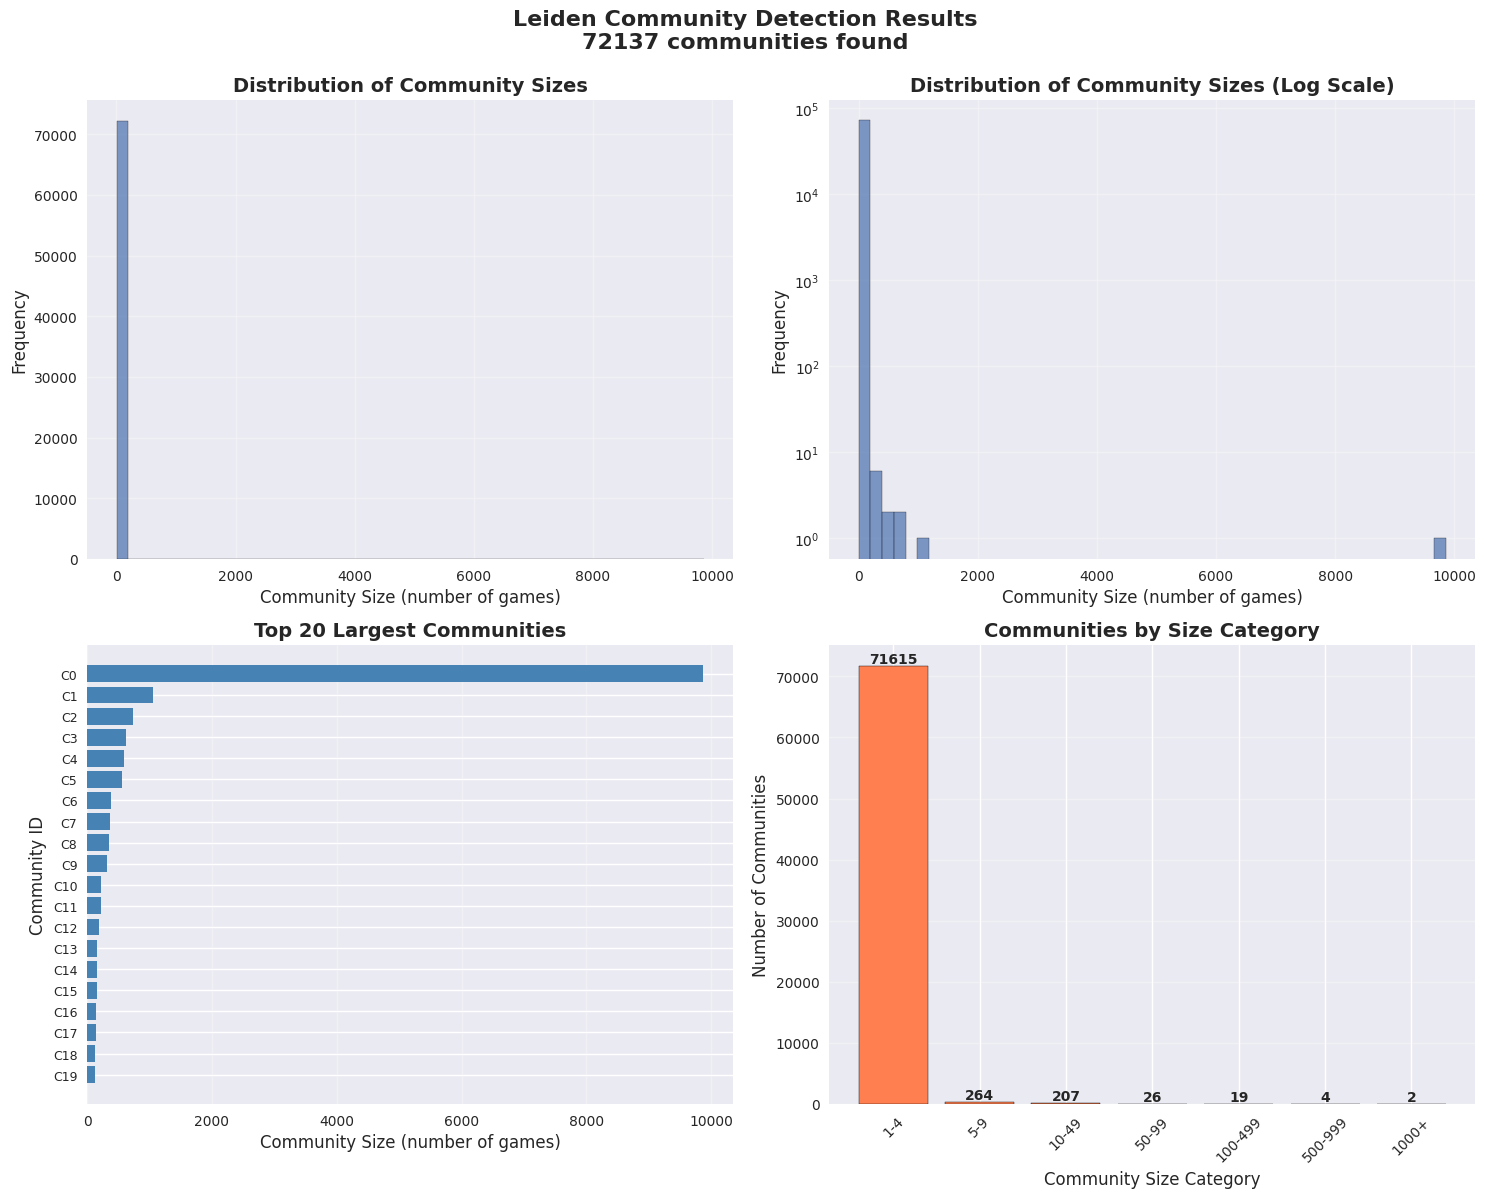

In [8]:
def generate_community_size_distribution_visualization(partition, community_stats, size_distribution):
  # Visualize community size distribution
  print("Generating community size distribution visualization...")

  fig, axes = plt.subplots(2, 2, figsize=(15, 12))

  # 1. Histogram of community sizes
  ax1 = axes[0, 0]
  ax1.hist(community_stats['size'], bins=50, edgecolor='black', alpha=0.7)
  ax1.set_xlabel('Community Size (number of games)', fontsize=12)
  ax1.set_ylabel('Frequency', fontsize=12)
  ax1.set_title('Distribution of Community Sizes', fontsize=14, fontweight='bold')
  ax1.grid(True, alpha=0.3)

  # 2. Log-scale histogram
  ax2 = axes[0, 1]
  ax2.hist(community_stats['size'], bins=50, edgecolor='black', alpha=0.7)
  ax2.set_xlabel('Community Size (number of games)', fontsize=12)
  ax2.set_ylabel('Frequency', fontsize=12)
  ax2.set_yscale('log')
  ax2.set_title('Distribution of Community Sizes (Log Scale)', fontsize=14, fontweight='bold')
  ax2.grid(True, alpha=0.3)

  # 3. Top 20 communities bar plot
  ax3 = axes[1, 0]
  top_20 = community_stats.head(20)
  ax3.barh(range(len(top_20)), top_20['size'], color='steelblue')
  ax3.set_yticks(range(len(top_20)))
  ax3.set_yticklabels([f"C{cid}" for cid in top_20['community_id']], fontsize=9)
  ax3.set_xlabel('Community Size (number of games)', fontsize=12)
  ax3.set_ylabel('Community ID', fontsize=12)
  ax3.set_title('Top 20 Largest Communities', fontsize=14, fontweight='bold')
  ax3.invert_yaxis()
  ax3.grid(True, alpha=0.3, axis='x')

  # 4. Size category distribution
  ax4 = axes[1, 1]
  size_dist_df = size_distribution.reset_index()
  size_dist_df.columns = ['Size Category', 'Count']
  ax4.bar(size_dist_df['Size Category'], size_dist_df['Count'], color='coral', edgecolor='black')
  ax4.set_xlabel('Community Size Category', fontsize=12)
  ax4.set_ylabel('Number of Communities', fontsize=12)
  ax4.set_title('Communities by Size Category', fontsize=14, fontweight='bold')
  ax4.tick_params(axis='x', rotation=45)
  ax4.grid(True, alpha=0.3, axis='y')

  # Add text annotations for counts
  for idx, row in size_dist_df.iterrows():
      ax4.text(idx, row['Count'], str(row['Count']), 
              ha='center', va='bottom', fontsize=10, fontweight='bold')

  plt.suptitle(f'Leiden Community Detection Results\n{len(partition)} communities found', 
              fontsize=16, fontweight='bold', y=0.995)
  plt.tight_layout()

  # Save the plot
  output_file = output_dir / 'community_size_distribution.png'
  plt.savefig(output_file, dpi=300, bbox_inches='tight')
  print(f"✓ Plot saved to {output_file}")

  plt.show()

generate_community_size_distribution_visualization(partition_0_5, partition_0_5_community_stats, partition_0_5_size_distribution)


### Community Detection Results (1.5 resolution)

In [19]:
partition_1_5_community_stats, partition_1_5_size_distribution = display_community_statistics(
    partition_1_5)

COMMUNITY STATISTICS

📊 Overall Statistics:
  Total communities: 80254
  Largest community: 6,385 vertices
  Smallest community: 1 vertices
  Mean community size: 1.22
  Median community size: 1.00

📈 Top 20 Largest Communities:
 community_id  size
            0  6385
            1   806
            2   558
            3   291
            4   278
            5   198
            6   174
            7   173
            8   162
            9   148
           10   139
           11   135
           12   108
           13   100
           14    97
           15    96
           16    96
           17    93
           18    82
           19    77

📉 Community Size Distribution:
  1-4         : 79777 communities
  5-9         :   283 communities
  10-49       :   166 communities
  50-99       :    14 communities
  100-499     :    11 communities
  500-999     :     2 communities
  1000+       :     1 communities



In [20]:
analyse_top_communities(partition_1_5, partition_1_5_community_stats)

TOP COMMUNITIES DETAILED ANALYSIS

Community #0 (Rank 1, Size: 6,385 games)

📊 Basic Metrics:
  Vertices: 6,385
  Edges: 16,240,881
  Density: 0.796867

📈 Degree Statistics (within community):
  Mean degree: 5087.20
  Max degree: 6,384
  Min degree: 1,544

🎮 Sample Games (top 10 by degree within community):
  • Counter-Strike                                     (community deg: 6364, total deg:  15365)
  • Orcs Must Die!                                     (community deg: 6359, total deg:  14894)
  • ORION: Prelude                                     (community deg: 6325, total deg:  13696)
  • Call of Duty®: Modern Warfare® 2 (2009)            (community deg: 6318, total deg:  13168)
  • Prototype™                                         (community deg: 6310, total deg:  12719)
  • Superliminal                                       (community deg: 6302, total deg:  16321)
  • Ori and the Will of the Wisps                      (community deg: 6298, total deg:  15067)
  • A Short Hike   

Generating community size distribution visualization...


✓ Plot saved to analysis_plots/community_size_distribution.png


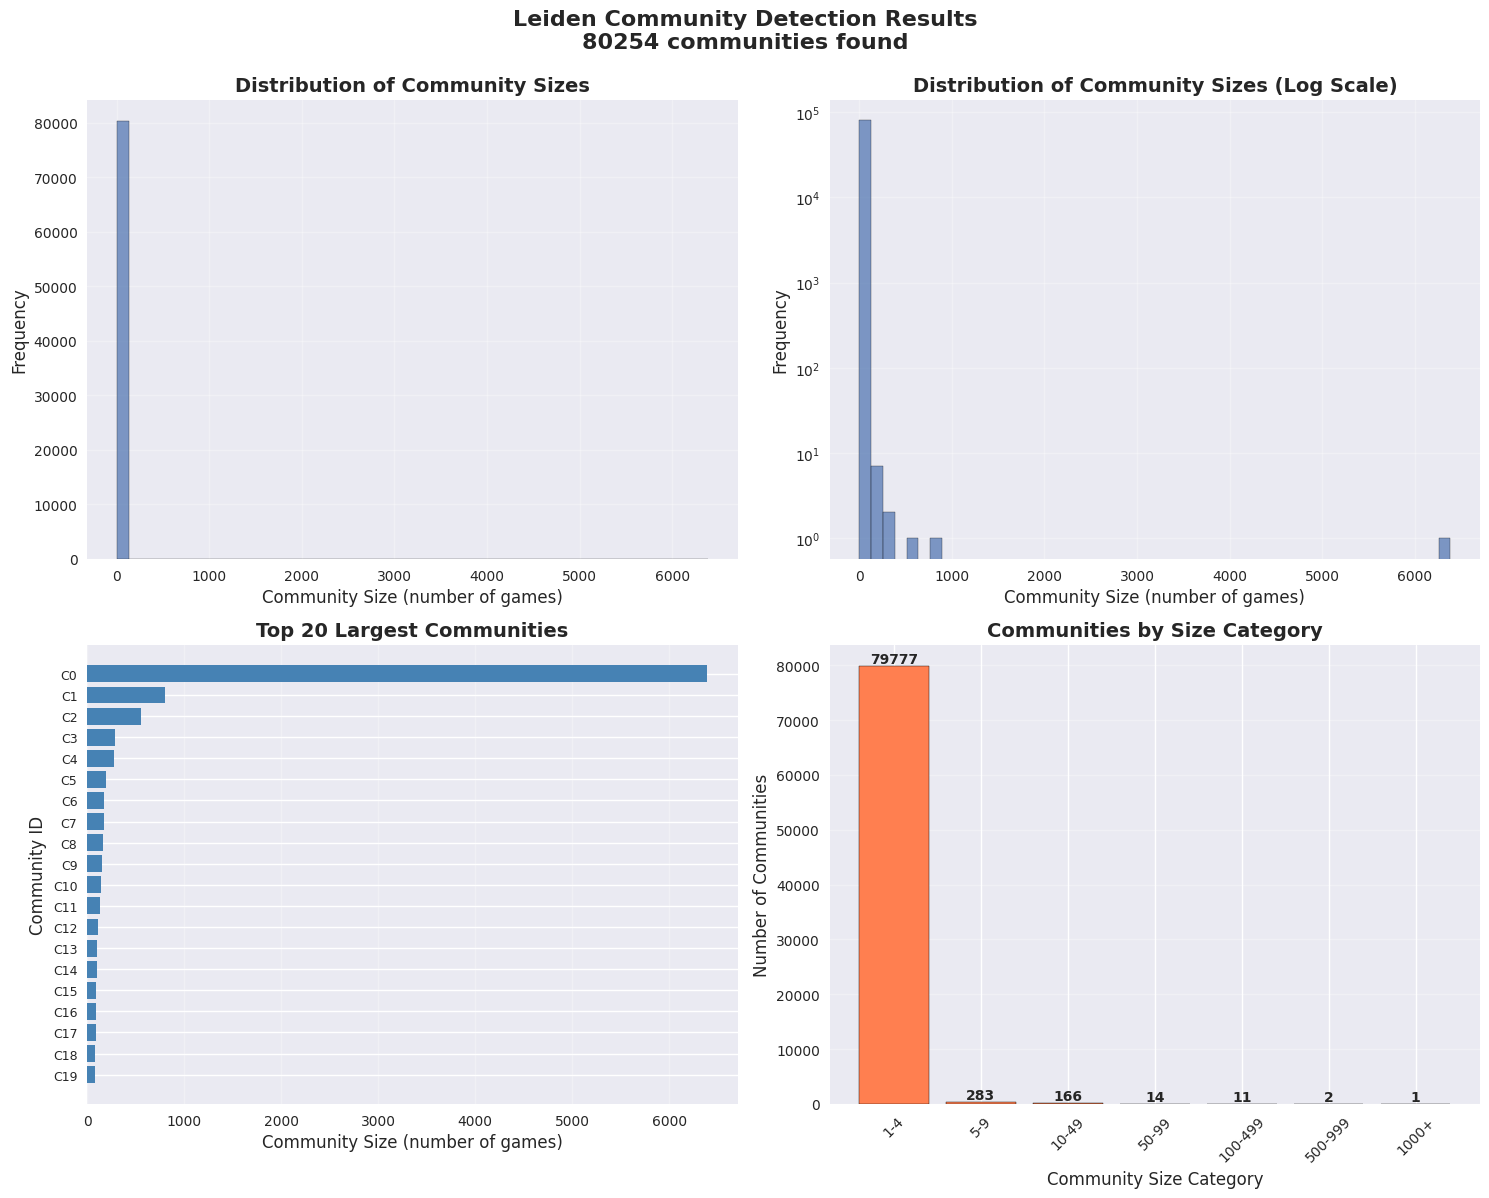

In [21]:
generate_community_size_distribution_visualization(
    partition_1_5, partition_1_5_community_stats, partition_1_5_size_distribution)

## Visualize communities with meta-graph

In [37]:
g.vs["size"] = 1

In [18]:
g.es["weight"]

[1889,
 13,
 2,
 1656,
 9,
 13,
 3,
 70,
 5,
 610,
 2914,
 485,
 450,
 16,
 6,
 2,
 3,
 3,
 145,
 3,
 351,
 36,
 3,
 168,
 9,
 17,
 6,
 3,
 29,
 92,
 1,
 1,
 6,
 1,
 26,
 4,
 1029,
 29,
 1,
 1,
 27,
 57,
 407,
 1,
 6,
 2,
 2,
 39,
 5,
 393,
 60,
 1,
 3,
 4,
 4,
 2,
 1,
 2,
 2,
 3,
 1,
 15,
 1,
 26,
 5,
 1,
 1,
 2,
 4,
 30,
 1,
 2,
 1,
 5,
 1,
 41,
 1,
 1,
 13,
 1,
 3,
 4,
 10,
 1,
 1,
 5,
 1,
 8,
 6,
 1,
 1,
 2,
 3,
 5,
 28,
 5,
 1,
 1,
 2,
 110,
 18,
 2,
 1,
 1,
 1,
 1,
 5,
 13,
 1,
 3,
 3,
 34,
 30,
 20,
 4,
 5,
 1,
 8,
 2,
 2,
 1,
 2,
 3,
 4,
 1,
 1,
 3,
 1,
 1,
 2,
 3,
 5,
 137,
 4,
 146,
 1,
 2,
 2,
 1,
 4,
 7,
 2,
 1,
 338,
 3,
 2,
 4,
 1,
 2,
 8,
 6,
 2,
 34,
 8,
 2,
 1,
 384,
 12,
 11,
 573,
 38,
 2,
 1,
 2,
 1,
 7,
 26,
 89,
 1,
 5,
 2,
 33,
 238,
 4,
 3,
 1,
 3,
 2,
 1,
 9,
 23,
 10,
 18,
 42,
 7,
 38,
 1,
 2,
 21,
 3,
 2,
 1,
 1,
 135,
 1,
 2,
 1,
 4,
 1,
 43,
 1,
 4,
 2,
 1,
 4,
 2,
 3,
 2,
 5,
 1,
 1,
 3,
 1,
 2,
 14,
 7,
 9,
 18,
 89,
 9,
 4,
 4,
 9,
 1,
 13,
 21,
 49,
 1

In [39]:
community_0_5_graph = partition.cluster_graph(
    combine_vertices={"size": "sum"},
    combine_edges={"weight": "sum"}
)

In [4]:
# community_0_5_graph.write_graphml("community_0.5_res_graph.graphml")
community_0_5_graph = ig.read("community_0.5_res_graph.graphml")
community_0_5_graph

In [ ]:
visual_style = {}
visual_style["vertex_size"] = [
    size / 100 for size in community_0_5_graph.vs["size"]]  # Scale as needed
visual_style["edge_width"] = [
    weight / 50 for weight in community_0_5_graph.es["weight"]]  # Scale as needed
visual_style["layout"] = community_0_5_graph.layout_fruchterman_reingold()

ig.plot(community_0_5_graph, "community_0_5_partition.png", **visual_style)

In [ ]:
community_1_5_graph = partition.cluster_graph(
    combine_vertices={"size": "sum"},
    combine_edges={"weight": "sum"}
)

In [ ]:
community_1_5_graph.write_graphml("community_1.5_res_graph.graphml")


In [ ]:
visual_style = {}
visual_style["vertex_size"] = [
    size / 100 for size in community_1_5_graph.vs["size"]]  # Scale as needed
visual_style["edge_width"] = [
    weight / 50 for weight in community_1_5_graph.es["weight"]]  # Scale as needed
visual_style["layout"] = community_1_5_graph.layout_fruchterman_reingold()

ig.plot(community_1_5_graph, "community_1_5_partition.png", **visual_style)